In [2]:
#imports:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np 
import read_spe as spe
import glob
import os

Reading in all files


#### if using Erin's folder setup (all power for each wavelength in one folder) using the following 2 cells to read in files

In [5]:
# p = r"D:\Karina Data 2.16.26\Empty"
# undoped_nm_dict = {}
# undoped_nm_settings_dict = {}
# for root, dirs, files in os.walk(p):
#     wavelength = os.path.basename(root)
#     power_dict = {}
#     power_dict_settings = {}
#     for file in files:
#         fp = os.path.join(root, file)
#         if ".txt" in file:      
#             if "SETTINGS" in os.path.basename(fp):
#                 name = os.path.basename(fp)
#                 power = name.split("_")[2]
#                 power = power.split("mW")[0]
#                 power_dict_settings[power] = pd.read_csv(fp, sep=":",header=None)
#             else:
#                 name = os.path.basename(fp)
#                 power = name.split("_")[2]
#                 power = power.split("mW")[0]
#                 power_dict[power] = pd.read_csv(fp, sep="\t")
#         else:
#             continue  
#     undoped_nm_dict[wavelength] = power_dict
#     undoped_nm_settings_dict[wavelength] = power_dict_settings

In [6]:
# p = r"D:\Karina Data 2.16.26\Doped"
# doped_nm_dict = {}
# doped_nm_settings_dict = {}
#     for root, dirs, files in os.walk(p):
#         wavelength = os.path.basename(root)
#         power_dict = {}
#         power_dict_settings = {}
#         for file in files:
#             fp = os.path.join(root, file)
#             if ".txt" in file:      
#                 if "SETTINGS" in os.path.basename(fp):
#                     name = os.path.basename(fp)
#                     power = name.split("_")[2]
#                     power=  power.split("mW")[0]
#                     power_dict_settings[power] = pd.read_csv(fp, sep=":",header=None)
#                 else:
#                     name = os.path.basename(fp)
#                     power = name.split("_")[2]
#                     power = power.split("mW")[0]
#                     power_dict[power] = pd.read_csv(fp, sep="\t")
#             else:
#                 continue
#     doped_nm_dict[wavelength] = power_dict
#     doped_nm_settings_dict[wavelength] = power_dict_settings

#### if using Karina's file setup (folder for each power inside each wavelength folder) use following 2 cells to read in files)

In [8]:
undoped_path = r"D:\Karina Data 2.16.26\Empty"
#set up dictionaries
undoped_nm_dict = {}
undoped_nm_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(undoped_path):
    print(wavelength_folder)
    wavelength_path = os.path.join(undoped_path, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".txt" in file:  
                #read in as settings file
                if "SETTINGS" in file:
                    power_settings_dict[power] = pd.read_csv(fp, sep=":", header=None)
                else:
                    #read in as power file
                    power_dict[power] = pd.read_csv(fp, sep="\t")
            else:
                continue

    undoped_nm_dict[wavelength] = power_dict
    undoped_nm_settings_dict[wavelength] = power_settings_dict

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Karina Data 2.16.26\\Empty'

In [ ]:
#repeat for doped
doped_path = r"D:\Karina Data 2.16.26\Doped"
doped_nm_dict = {}
doped_nm_settings_dict = {}
for wavelength_folder in os.listdir(doped_path):
    wavelength_path = os.path.join(doped_path, wavelength_folder)
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        power = power.replace(" mW","")
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".txt" in file:
                if "SETTINGS" in file:
                    power_settings_dict[power] = pd.read_csv(fp, sep=":", header=None)
                else:
                    power_dict[power] = pd.read_csv(fp, sep="\t")
            else:
                continue
    doped_nm_dict[wavelength] = power_dict
    doped_nm_settings_dict[wavelength] = power_settings_dict

In [ ]:
print(undoped_nm_dict['757'].keys())

In [ ]:
#needs to be same length as doped - if this is not an issue, comment out this cell
del undoped_nm_dict['721']['5']

In [ ]:
#sorting to make sure powers are in order
undoped_nm_dict = {k: v for k, v in sorted(undoped_nm_dict.items(), key=lambda item: item[0])}
undoped_nm_settings_dict = {k: v for k, v in sorted(undoped_nm_settings_dict.items(), key=lambda item: item[0])}
doped_nm_dict = {k: v for k, v in sorted(doped_nm_dict.items(), key=lambda item: item[0])}
doped_nm_settings_dict = {k: v for k, v in sorted(undoped_nm_settings_dict.items(), key=lambda item: item[0])}

In [ ]:
#convert dictionaries to lists for easier indexing
undoped_nm = []
for wavelength in undoped_nm_dict:
    power_dict = undoped_nm_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_nm.append(power_list)

undoped_settings_nm = []
for wavelength in undoped_nm_settings_dict:
    power_dict = undoped_nm_settings_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_settings_nm.append(power_list)

doped_nm = []
for wavelength in doped_nm_dict:
    power_dict = doped_nm_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_nm.append(power_list)

doped_settings_nm = []
for wavelength in doped_nm_settings_dict:
    power_dict = doped_nm_settings_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_settings_nm.append(power_list)


In [12]:
#find average voltage for each undoped file, add them to a new list
#do the same with uncertainties
averageVoltageUndoped = []
for wavelength in undoped_nm: 
    wavelengthVoltageUndoped = []
    for power in wavelength:
        wavelengthVoltageUndoped.append(power.iloc[:,2].mean())
    averageVoltageUndoped.append(wavelengthVoltageUndoped)

NameError: name 'undoped_nm' is not defined

In [14]:
#convert power meter range (W) to mW
pwr = 1.451223E-02 * 1000
#IF POWER RANGE IS NOT HTE SAME FOR EACH, MAKE SURE TO CHANGE PWR TO (doped_settings_nm[i][j].iloc[3,1])
#Erin's code says divide it by 2, not really sure why 
#power = voltage x power range / 2
#convert from V to mW
averagePowerUndoped = []
uncertaintyPowerUndoped = []
for i in range(len(undoped_nm)):
    wavelengthPowerUndoped = []
    wavelengthPowerUncertaintyUndoped = []
    for j in range(len(undoped_nm[i])):
        wavelengthPowerUndoped.append(averageVoltageUndoped[i][j] * pwr/2)
        wavelengthPowerUncertaintyUndoped.append((undoped_nm[i][j].iloc[:,2] * (pwr/2)).std() / np.sqrt(103))
    averagePowerUndoped.append(wavelengthPowerUndoped)
    uncertaintyPowerUndoped.append(wavelengthPowerUncertaintyUndoped)

NameError: name 'undoped_nm' is not defined

In [15]:
#find average counts per frame
averageCountsUndoped = []
uncertaintyCountsUndoped = []
cpsUndoped = []
uncertaintyCpsUndoped = []
for i in range(len(undoped_nm)):
    wavelengthCountsUndoped = []
    wavelengthCountsUndopedUncertainty = []
    for j in range(len(undoped_nm[i])):
        wavelengthCountsUndoped.append((undoped_nm[i][j].iloc[:,4].mean()))
        wavelengthCountsUndopedUncertainty.append((undoped_nm[i][j].iloc[:,4].std()))
    averageCountsUndoped.append(wavelengthCountsUndoped)
    uncertaintyCountsUndoped.append(wavelengthCountsUndopedUncertainty)
#now counts per second, divide average by exposure time (from settings files)
for i in range(len(undoped_nm)):
    wavelengthCps = []
    wavelengthUncertaintyCps = []
    for j in range(len(undoped_nm[i])):
        wavelengthCps.append(averageCountsUndoped[i][j]/undoped_settings_nm[0][0].iloc[1,1])
        wavelengthUncertaintyCps.append((uncertaintyCountsUndoped[i][j]/undoped_settings_nm[0][0].iloc[1,1])/np.sqrt(103))
    cpsUndoped.append(wavelengthCps)
    uncertaintyCpsUndoped.append(wavelengthUncertaintyCps)

5


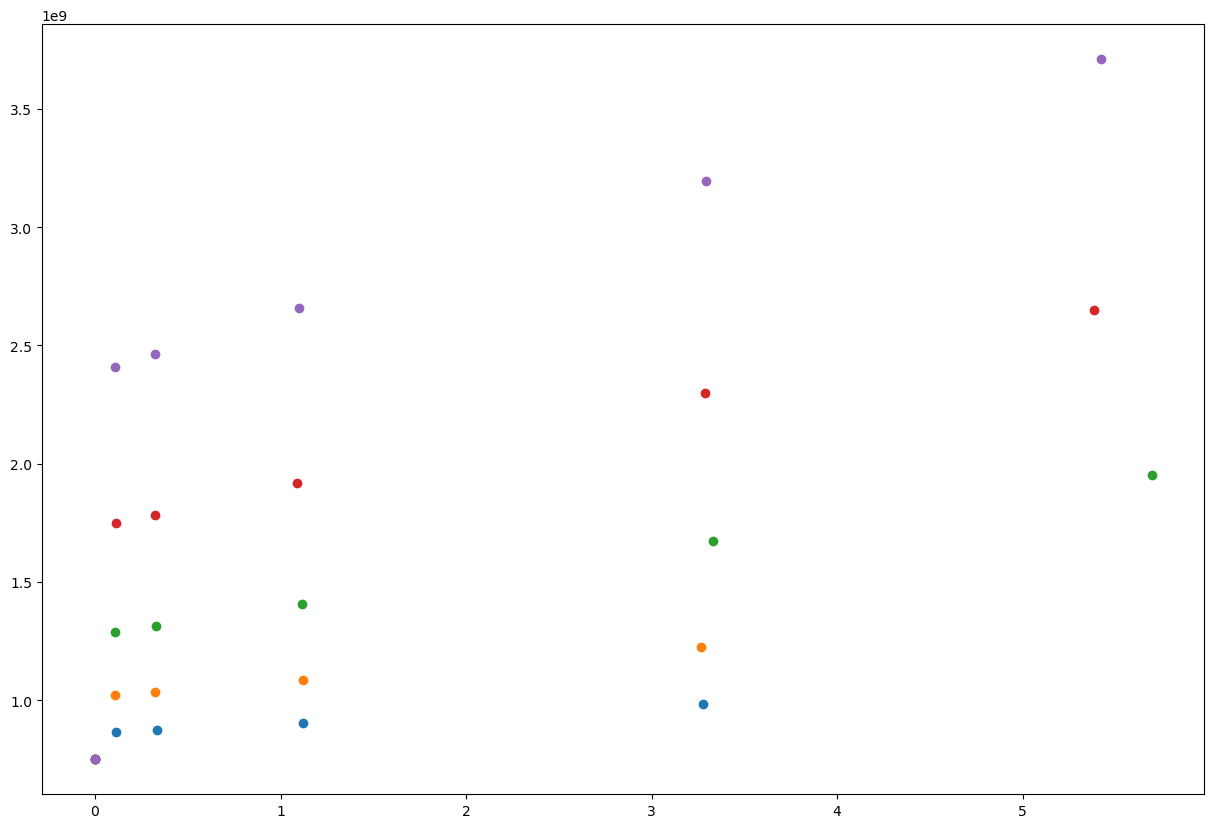

In [16]:
print(len(cpsUndoped))
for i in range(len(averagePowerUndoped)):
    plt.scatter(averagePowerUndoped[i],averageCountsUndoped[i])

In [17]:
#find average voltage for each doped file, add them to a new list
#do the same with uncertainties
averageVoltageDoped = []
for wavelength in doped_nm: 
    wavelengthVoltageDoped = []
    for power in wavelength:
        wavelengthVoltageDoped.append(power.iloc[:,2].mean())
    averageVoltageDoped.append(wavelengthVoltageDoped)

In [18]:
#convert power meter range (W) to mW
#convert from V to mW
averagePowerDoped = []
uncertaintyPowerDoped = []
for i in range(len(doped_nm)):
    wavelengthPowerDoped = []
    wavelengthPowerUncertaintyDoped = []
    for j in range(len(doped_nm[i])):
        wavelengthPowerDoped.append(averageVoltageDoped[i][j] * (pwr/2))
        wavelengthPowerUncertaintyDoped.append((doped_nm[i][j].iloc[:,2] * (pwr/2)).std() / np.sqrt(103))
    averagePowerDoped.append(wavelengthPowerDoped)
    uncertaintyPowerDoped.append(wavelengthPowerUncertaintyDoped)

In [19]:
#find average counts per frame
averageCountsDoped = []
uncertaintyCountsDoped = []
cpsDoped = []
uncertaintyCpsDoped = []
for i in range(len(doped_nm)):
    wavelengthCountsDoped = []
    wavelengthCountsDopedUncertainty = []
    for j in range(len(doped_nm[i])):
        wavelengthCountsDoped.append((doped_nm[i][j].iloc[:,4].mean()))
        wavelengthCountsDopedUncertainty.append((doped_nm[i][j].iloc[:,4].std()))
    averageCountsDoped.append(wavelengthCountsDoped)
    uncertaintyCountsDoped.append(wavelengthCountsDopedUncertainty)
#now counts per second, divide average by exposure time (from settings files)
for i in range(len(averageCountsDoped)):
    wavelengthCps = []
    wavelengthUncertaintyCps = []
    for j in range(len(averageCountsDoped[i])):
        wavelengthCps.append(averageCountsDoped[i][j]/doped_settings_nm[0][0].iloc[1,1])
        wavelengthUncertaintyCps.append((uncertaintyCountsDoped[i][j]/doped_settings_nm[0][0].iloc[1,1])/np.sqrt(103))
    cpsDoped.append(wavelengthCps)
    uncertaintyCpsDoped.append(wavelengthUncertaintyCps)

In [359]:
print(doped_settings_nm[0][0].iloc[1,1])

0.01


In [20]:
#now read in bias data (no film)
#THIS IS ERIN"S BIAS DATA!! DOES NOT WORK RIGHT NOW FOR KARINA"S NEW DATA!!
bias = pd.read_csv(
    r"C:\Users\summe\OneDrive\Desktop\FRIB\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342.txt"
    , sep="\t")
bias_settings = pd.read_csv(
    r"C:\Users\summe\OneDrive\Desktop\FRIB\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342_SETTINGS.txt"
                            , header=None, sep=":")
#find average counts
bias_avg_counts = bias.iloc[:,4].mean()
#find counts per second
bias_cps = bias_avg_counts / (doped_settings_nm[0][0].iloc[1,1])
#uncertainty
bias_uncertainty = np.std(bias.iloc[:,4]) / np.sqrt(103)

In [21]:
#subtract bias from doped and undoped datas
cpsDopedNoBias = []
for i in cpsDoped:
    cpsDopedNoBias.append(i-bias_cps)
cpsUndopedNoBias = []
for i in cpsUndoped:
    cpsUndopedNoBias.append(i-bias_cps)

In [22]:
#blah blah bias stuff
cpsUndopedArray = []
cpsUndopedNBArray = []
cpsDopedArray = []
cpsDopedNBArray = []
for i in range(len(cpsUndoped)):
    cpsUndopedArray.append(np.array(cpsUndoped[i]))
    cpsUndopedNBArray.append(np.array(cpsUndopedNoBias[i]))
for i in range(len(cpsDoped)):
    cpsDopedArray.append(np.array(cpsDoped[i]))
    cpsDopedNBArray.append(np.array(cpsDopedNoBias[i]))

Text(0.5, 1.0, 'Total Counts/s in Empty Kr Film')

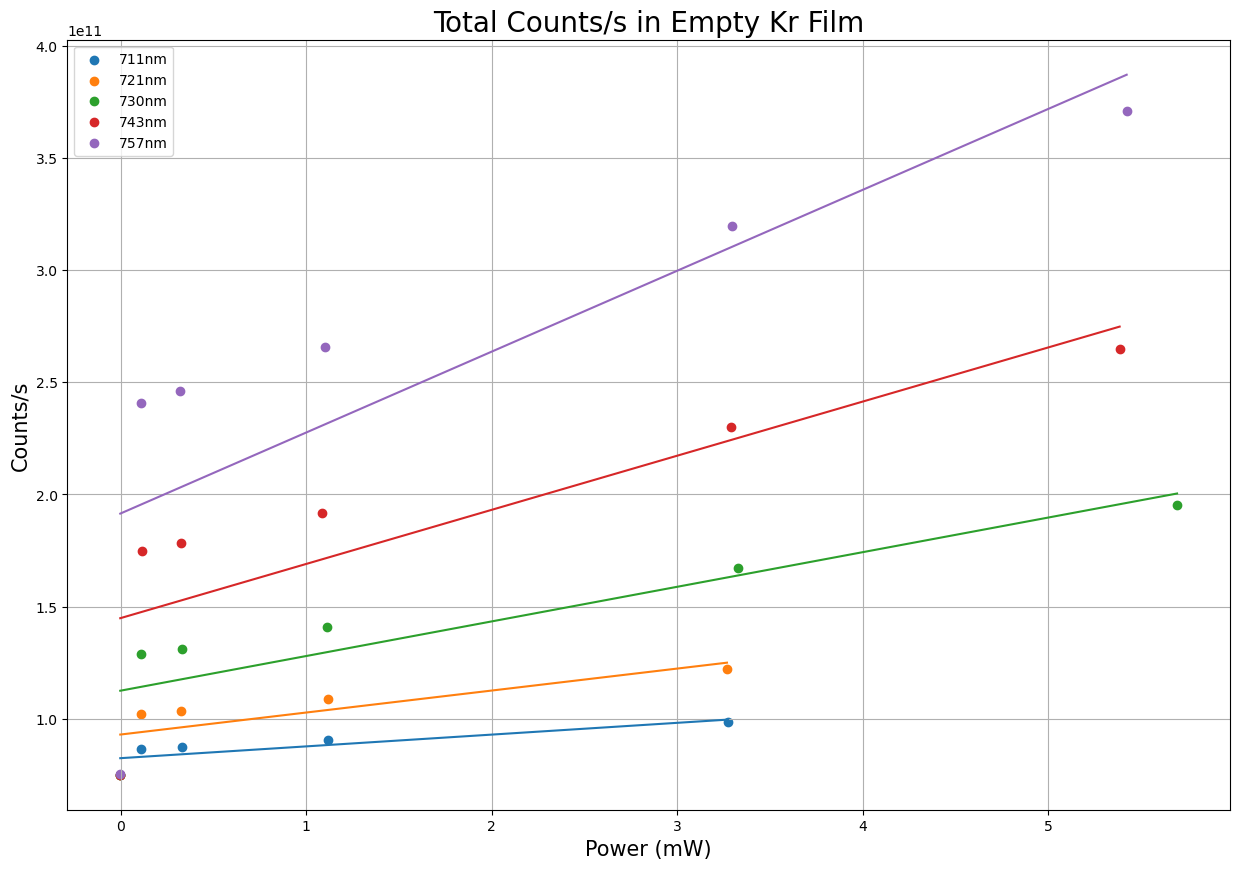

In [24]:
plt.figure(figsize=(15,10))
for i in range(len(cpsUndoped)):
    trend = np.polyfit(averagePowerUndoped[i], cpsUndoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerUndoped[i], plot(averagePowerUndoped[i]))
    plt.scatter(averagePowerUndoped[i], cpsUndoped[i], label=list(undoped_nm_dict)[i]+"nm")
plt.legend()
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("Total Counts/s in Empty Kr Film", fontsize=20)

Text(0.5, 1.0, 'Total Counts/s in Rb Doped Kr Film')

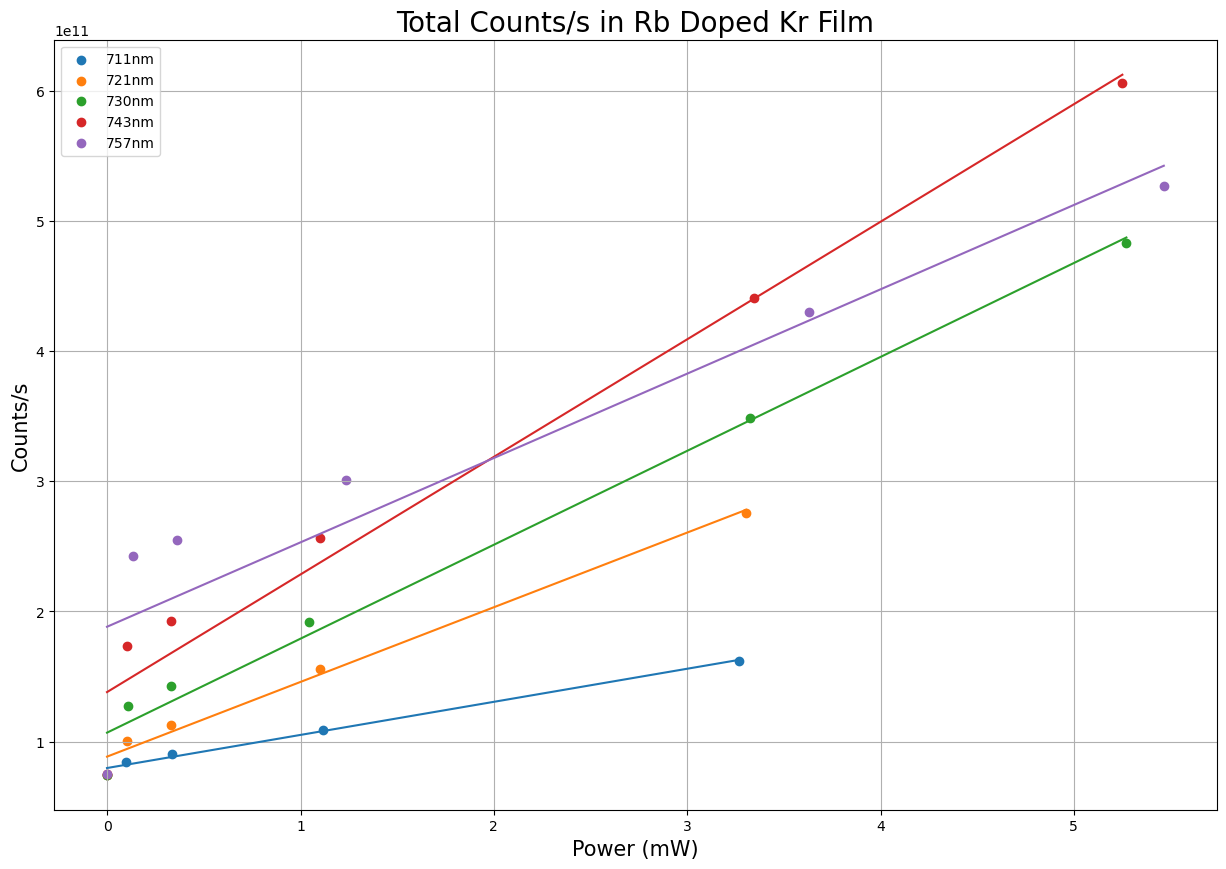

In [25]:
plt.figure(figsize=(15,10))
for i in range(len(cpsDoped)):
    trend = np.polyfit(averagePowerDoped[i], cpsDoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]))
    plt.scatter(averagePowerDoped[i], cpsDoped[i], label=list(doped_nm_dict)[i]+"nm")
plt.legend()
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("Total Counts/s in Rb Doped Kr Film", fontsize=20)

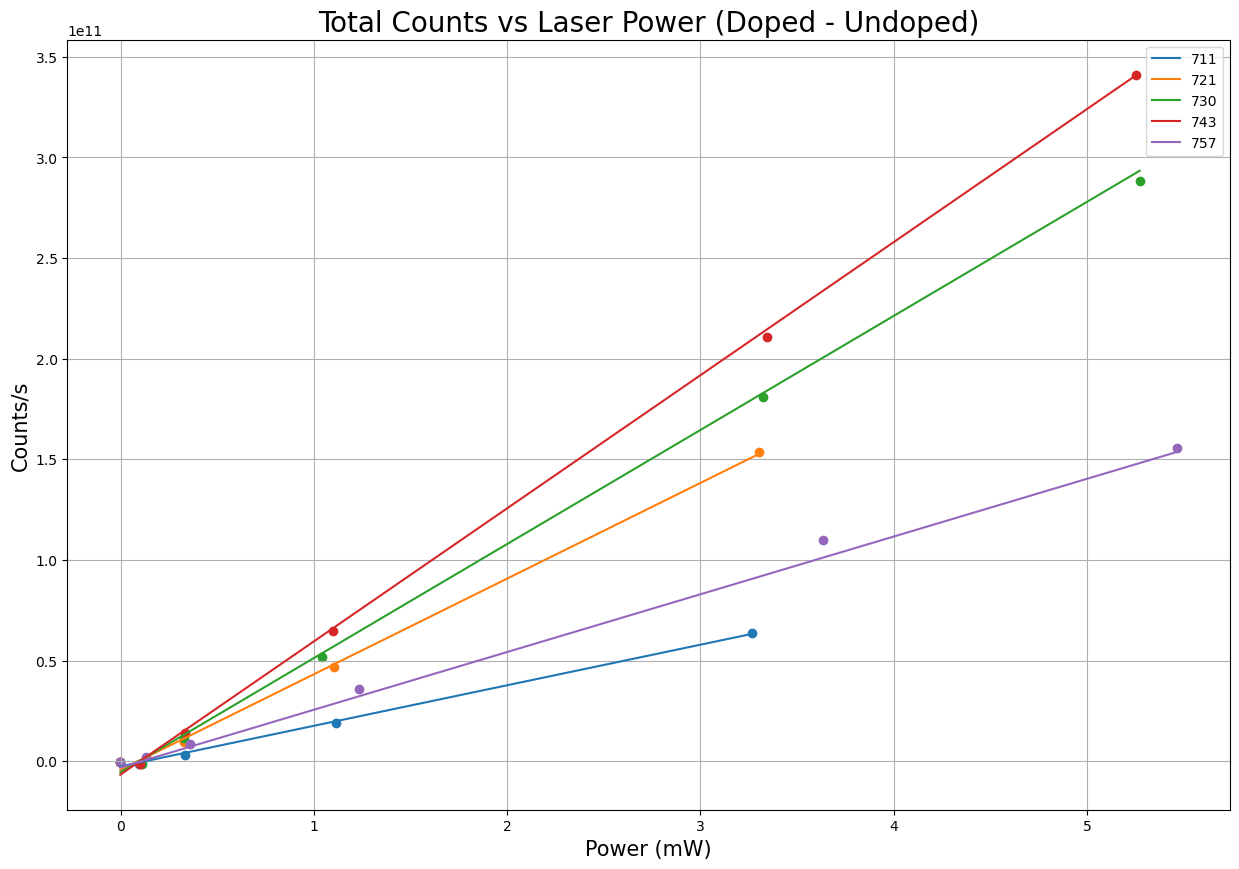

In [26]:
plt.figure(figsize=(15,10))
for i in range(len(cpsDoped)):
    trend = np.polyfit(averagePowerDoped[i], cpsDoped[i], 1)
    trend1 = np.polyfit(averagePowerUndoped[i], cpsUndoped[i], 1)
    diff = trend - trend1
    plot = np.poly1d(diff)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]), label=list(doped_nm_dict)[i])
    plt.scatter(averagePowerDoped[i], np.array(cpsDoped[i]) - np.array(cpsUndoped[i]))
plt.legend()
plt.title("Total Counts vs Laser Power (Doped - Undoped)", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.grid()

In [27]:

p = r"D:\Karina Data 2.16.26\Empty"
#set up dictionaries
undoped_spe_dict = {}
undoped_spe_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(p):
    wavelength_path = os.path.join(p, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".spe" in file:  
                #read in as settings file
                if "SETTINGS" in file:
                    spa = spe.SpeReference(fp)
                    #convert spe file to array right now so I don't have to worry about it later
                    #also change type to float32 instead of 64 so it reads in faster 
                    #also drop the first dimension so it's only frames, y, x
                    test = np.array(spe.SpeReference.get_data(spa), dtype=np.float32)[0]
                    power_settings_dict[power] = test
                else:
                 #   print("UNDOPED:", fp)
                    spo = spe.SpeReference(fp)
                    test2 = np.array(spe.SpeReference.get_data(spo),dtype=np.float32)[0]
                    power_dict[power] = test2
            else:
                continue

    undoped_spe_dict[wavelength] = power_dict
    undoped_spe_settings_dict[wavelength] = power_settings_dict

In [28]:
p = r"D:\Karina Data 2.16.26\Doped"
#set up dictionaries
doped_spe_dict = {}
doped_spe_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(p):
    wavelength_path = os.path.join(p, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".spe" in file:  
                #read in as settings file
                if "SETTINGS" in file:
                    spa = spe.SpeReference(fp)
                    #convert spe file to array right now so I don't have to worry about it later
                    #also change type to float32 instead of 64 so it reads in faster 
                    #also drop the first dimension so it's only frames, y, x
                    test = np.array(spe.SpeReference.get_data(spa), dtype=np.float32)[0]
                    power_settings_dict[power] = test
                else:
                 #   print("UNDOPED:", fp)
                    spo = spe.SpeReference(fp)
                    test2 = np.array(spe.SpeReference.get_data(spo),dtype=np.float32)[0]
                    power_dict[power] = test2
            else:
                continue
    doped_spe_dict[wavelength] = power_dict
    doped_spe_settings_dict[wavelength] = power_settings_dict

In [29]:
print(list(doped_spe_dict.keys()))
print(list(undoped_spe_dict.keys()))

['721', '730', '743', '757', '711']
['730', '743', '757', '711', '721']


In [30]:
#sort by wavelength
undoped_spe_dict = {k: v for k, v in sorted(undoped_spe_dict.items(), key=lambda item: item[0])}
doped_spe_dict = {k: v for k, v in sorted(doped_spe_dict.items(), key=lambda item: item[0])}


In [31]:
print(list(undoped_nm_dict.keys()))
print(list(undoped_spe_dict.keys()))

['711', '721', '730', '743', '757']
['711', '721', '730', '743', '757']


In [32]:
#convert to lists
undoped_spe = []
for wavelength in undoped_spe_dict:
    power_dict = undoped_spe_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_spe.append(power_list)
doped_spe = []
for wavelength in doped_spe_dict:
    power_dict = doped_spe_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_spe.append(power_list)

In [34]:
#set region of interest (ROI)
#I'm using Erin's 
roi_x1 = 390
roi_x2 = 700
roi_y1 = 450
roi_y2 = 700
#roi sizes
roi_x = roi_x2 - roi_x1
roi_y = roi_y2 - roi_y1
#also define total area
x_size = 1024
y_size = 1024

In [35]:
#get roi lists
undoped_spe_roi = []
for wavelength in undoped_spe: 
    roi = []
    for power in wavelength:
        roi.append(power[:, roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    undoped_spe_roi.append(roi)
doped_spe_roi = []
for wavelength in doped_spe: 
    roi = []
    for power in wavelength:
        roi.append(power[:, roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    doped_spe_roi.append(roi)

In [36]:
print(np.shape(undoped_spe_roi[0][0]))

(103, 251, 311)


In [206]:
#find total counts for whole frame
undoped_total = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in undoped_spe]
doped_total = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in doped_spe]

In [38]:
#find total counts for roi
undoped_avgs = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in undoped_spe_roi]
doped_avgs = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in doped_spe_roi]

In [39]:
for i in range(len(averagePowerDoped)):
    print(len(averagePowerDoped[i]))
    print(len(averagePowerUndoped[i]))

5
5
5
5
6
6
6
6
6
6


In [40]:
#find counts per second for roi
cps_undoped = [[power/doped_settings_nm[0][0].iloc[1,1]  for power in wavelength] for wavelength in undoped_avgs]
cps_doped = [[power/doped_settings_nm[0][0].iloc[1,1]  for power in wavelength] for wavelength in doped_avgs]

In [207]:
#find counts per second for full frame
cps_total_u = [[power/doped_settings_nm[0][0].iloc[1,1]  for power in wavelength] for wavelength in undoped_total]
cps_total_d = [[power/doped_settings_nm[0][0].iloc[1,1]  for power in wavelength] for wavelength in doped_total]

In [42]:
# cps_total_u[1] = cps_total_u[1][:5]

# for i in range(len(cps_total_u)):
#     plt.scatter(averagePowerUndoped[i],cps_total_u[i], color='c')
#     plt.scatter(averagePowerUndoped[i], cpsUndoped[i],color='r')

In [43]:
cps_undoped[1] = cps_undoped[1][:5]
# cps_doped = cps_doped[:5]

In [44]:
print(list(undoped_spe_dict['711'].keys()))
print(list(doped_spe_dict['711'].keys()))

['0', '0.1', '0.3', '1', '3']
['0', '0.1', '0.3', '1', '3']


Text(0.5, 1.0, 'ROI counts in undoped Kr film')

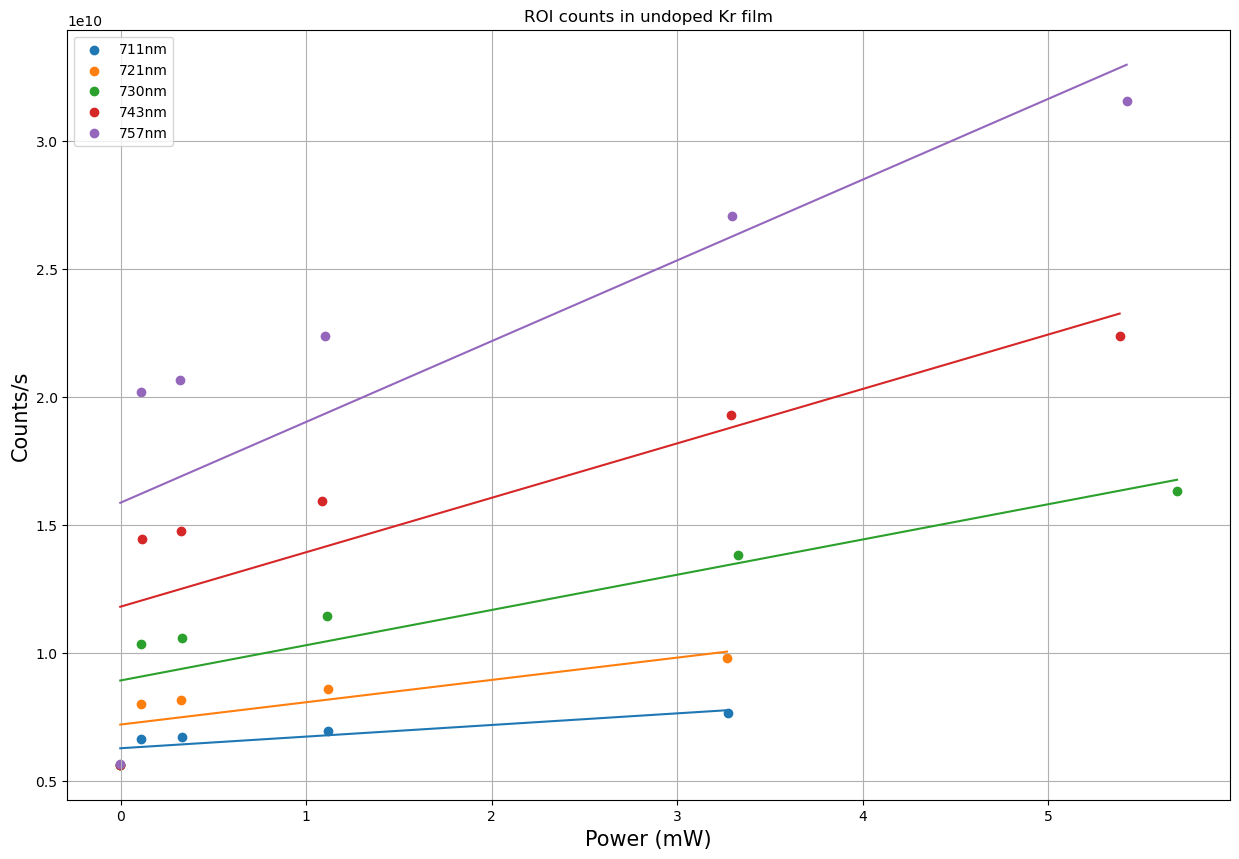

In [45]:
plt.figure(figsize=(15,10))
for i in range(len(cps_undoped)):
    trend = np.polyfit(averagePowerUndoped[i], cps_undoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerUndoped[i], plot(averagePowerUndoped[i]))
    plt.scatter(averagePowerUndoped[i], cps_undoped[i], label=list(undoped_spe_dict)[i]+"nm")
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.legend()
plt.title("ROI counts in undoped Kr film")

Text(0.5, 1.0, 'ROI Counts in Rb Doped Krypton Film')

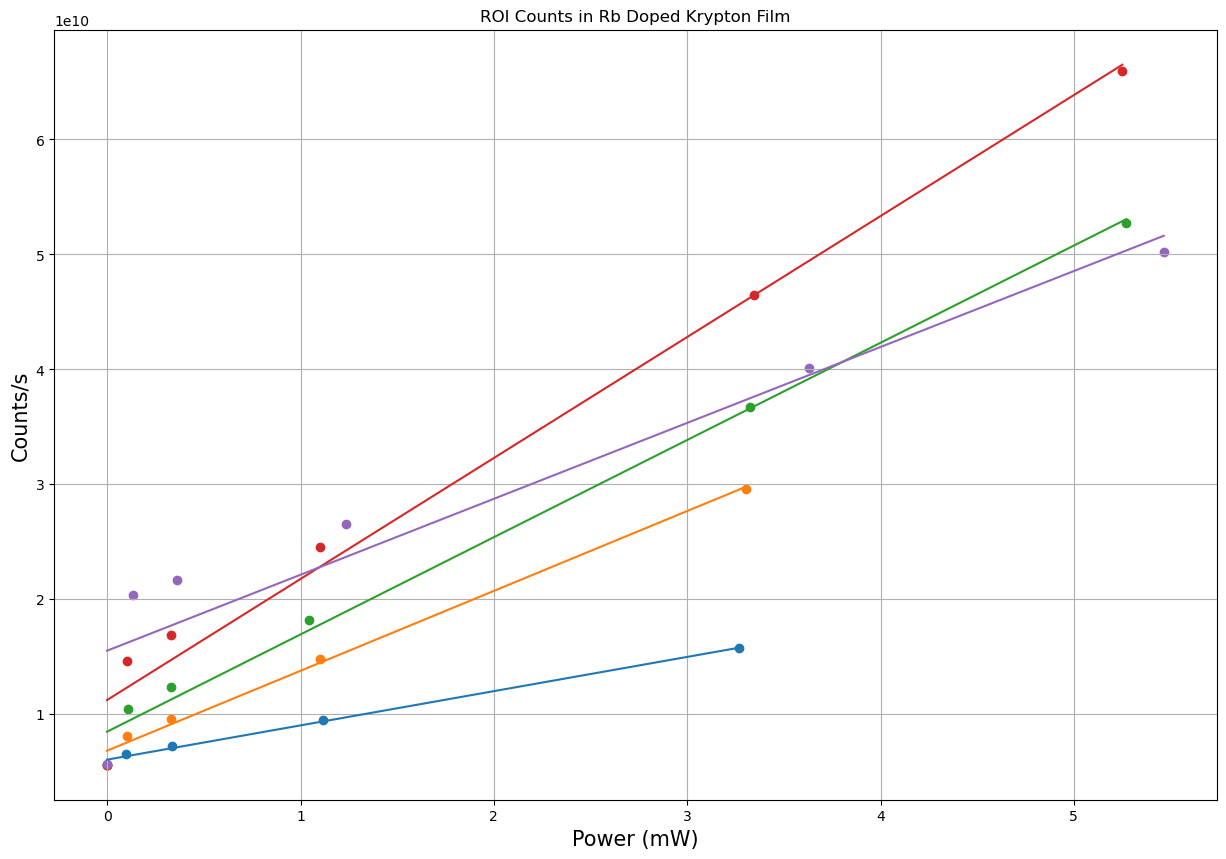

In [46]:
plt.figure(figsize=(15,10))
for i in range(len(cps_doped)):
    trend = np.polyfit(averagePowerDoped[i], cps_doped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]))
    plt.scatter(averagePowerDoped[i], cps_doped[i], label=list(doped_spe_dict)[i]+"nm")
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("ROI Counts in Rb Doped Krypton Film")

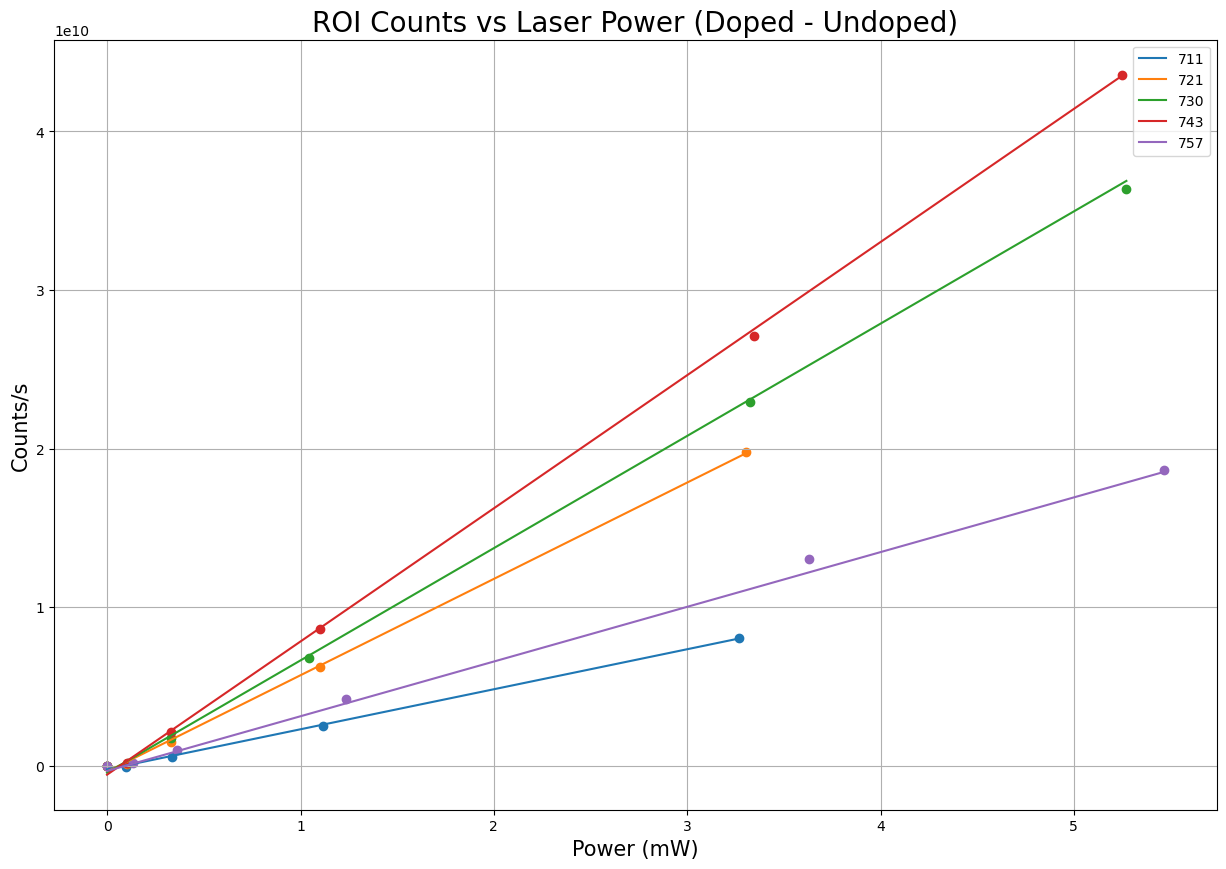

In [47]:
plt.figure(figsize=(15,10))
for i in range(len(cps_doped)):
    trend = np.polyfit(averagePowerDoped[i], cps_doped[i], 1)
    trend1 = np.polyfit(averagePowerUndoped[i], cps_undoped[i], 1)
    diff = trend - trend1
    plot = np.poly1d(diff)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]), label=list(doped_spe_dict)[i])
    plt.scatter(averagePowerDoped[i], np.array(cps_doped[i]) - np.array(cps_undoped[i]))
plt.legend()
plt.title("ROI Counts vs Laser Power (Doped - Undoped)", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.grid()

In [94]:
#find average counts for each pixel in the ROI
cpp_undoped = [[(np.mean(power, axis=(0))/doped_settings_nm[0][0].iloc[1,1]) for power in wavelength] for wavelength in undoped_spe_roi]
cpp_doped = [[(np.mean(power, axis=(0))/doped_settings_nm[0][0].iloc[1,1]) for power in wavelength] for wavelength in doped_spe_roi]

In [95]:
#define important stuff
substrate_width = 2.54 #cm
pixel_area = (substrate_width / x_size)**2 #cm^2
pixel_width = substrate_width / x_size

In [214]:
#find average counts for each pixel in the full frame
cpp_undoped_tot = [[(np.mean(power, axis=(0))/doped_settings_nm[0][0].iloc[1,1]) for power in wavelength] for wavelength in undoped_spe]
cpp_doped_tot = [[(np.mean(power, axis=(0))/doped_settings_nm[0][0].iloc[1,1]) for power in wavelength] for wavelength in doped_spe]

In [100]:
#find intensity (assuming power is evenly distributed)
intensity_undoped = []
for wavelength in averagePowerUndoped: 
    intensity = []
    for power in wavelength:
        intensity.append(power / (x_size * y_size * pixel_area))
    intensity_undoped.append(intensity)

intensity_doped = []
for wavelength in averagePowerDoped: 
    intensity = []
    for power in wavelength:
        intensity.append(power / (x_size * y_size * pixel_area))
    intensity_doped.append(intensity)

In [190]:
print(intensity_doped[1][1])
print

0.016119351757899185


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [232]:
#cut everything down
#i need a better way to do this but i have not had the time and rn it's the least of my worries
for i in range(len(cpp_undoped)):
    cpp_undoped[i] = np.array(cpp_undoped[i])[:5]
    cpp_doped[i] = np.array(cpp_doped[i])[:5]
    intensity_doped[i] = np.array(intensity_doped[i])[:5]
    cpp_doped[i] = cpp_doped[i][:5]
    intensity_undoped[i] = intensity_undoped[i][:5]
    cpp_doped_tot[i] = cpp_doped_tot[i][:5]
    cpp_undoped_tot[i] = cpp_undoped_tot[i][:5]

    
    

In [108]:
#calculate slopes for each pixel (evenly distributed model)
allrows= []
for i in range(len(cpp_undoped)):
    rows = []
    for y in range(roi_y):
        for x in range(roi_x):
            best, ignore = np.polyfit(intensity_doped[i], cpp_doped[i][:,y,x], 1)
            best1, ignore = np.polyfit(intensity_undoped[i], cpp_undoped[i][:,y,x], 1)
            rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})
    allrows.append(rows)

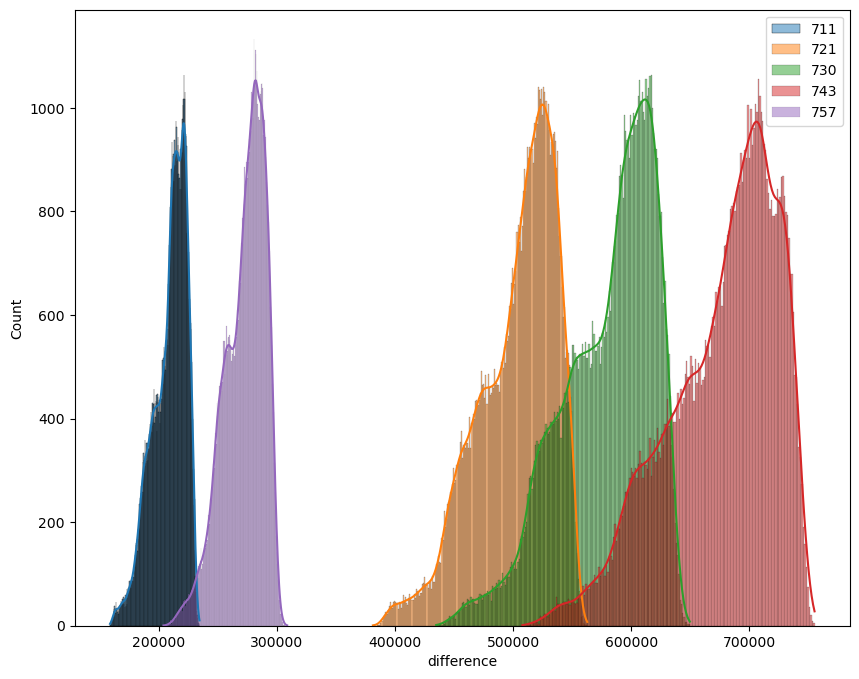

In [109]:
#graph

bins=200
plt.figure(figsize=(10,8))
for i in range(len(allrows)):
    slopes_table = pd.DataFrame(allrows[i])
    sns.histplot(slopes_table["difference"], kde=True, bins=bins,  label=list(undoped_spe_dict)[i])

plt.legend()

In [110]:
print(np.shape(cpp_undoped))

(5, 5, 251, 311)


In [111]:
#find the fraction of counts at each pixel for the undoped frame in the ROI
fractionalCounts = []
for wavelength in cpp_undoped: 
    fraction = []
    for power in wavelength:
        fraction.append(power/ np.sum(power))
    fractionalCounts.append(fraction)

In [234]:
#find the fraction of counts at each pixel for the undoped frame in the full frame

fractionalCountsTotal = []
for wavelength in cpp_undoped_tot: 
    fraction = []
    for power in wavelength:
        fraction.append(power/ np.sum(power))
    fractionalCountsTotal.append(fraction)

In [236]:
for i in range(len(averagePowerUndoped)):
    print(len(averagePowerUndoped[i]))
    print(len(fractionalCountsTotal[i]))

5
5
5
5
6
5
6
5
6
5


In [238]:
#find normalized power
normalized_power_undoped = []
normalized_power_doped = []
for i in range(len(fractionalCountsTotal)):
    norm = []
    norm_doped = []
    for j in range(len(fractionalCountsTotal[i])):
        #multiply the average total power by the percent of power at that pixel to get a per pixel power aka intensity
        norm.append(averagePowerUndoped[i][j] * fractionalCountsTotal[i][j])
        norm_doped.append(averagePowerDoped[i][j] * fractionalCountsTotal[i][j])
    normalized_power_undoped.append(norm)
    normalized_power_doped.append(norm_doped)

In [280]:
#divide by area to get an intensity per cm^2
normalized_power_area_undoped = [[power/pixel_area for power in wavelength] for wavelength in normalized_power_undoped]
normalized_power_area_doped = [[power/pixel_area for power in wavelength] for wavelength in normalized_power_doped]

In [242]:
print(cps_total_u)

[[74982073600.0, 86339552000.0, 87213856000.0, 90250483200.0, 98448416000.0], [74994521600.0, 102222400000.0, 103614291200.0, 108681971200.0, 122281868800.0, 137500620800.0], [75045331200.0, 128658944000.0, 131271398400.0, 140658291200.0, 167285580800.0, 195181593600.0], [75069299200.0, 174894822400.0, 178451763200.0, 191810124800.0, 229903872000.0, 265049728000.0], [75200825600.0, 240931097600.0, 246222208000.0, 265659059200.0, 319658956800.0, 371037209600.0]]


In [282]:
print((normalized_power_area_undoped[0][3].mean()))
print(intensity_undoped[0][3])

0.17343499
0.17343501934412195


In [278]:
#change all to arrays
for i in range(len(normalized_power_area_undoped)):
    normalized_power_area_undoped[i] = np.array(normalized_power_area_undoped[i])
    normalized_power_area_doped[i] = np.array(normalized_power_area_doped[i])
print(np.shape(normalized_power_area_undoped[0]))

(5, 1024, 1024)


In [310]:
#cut normalized power down to roi
undoped_roi_pwr = []
for wavelength in normalized_power_area_undoped: 
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    undoped_roi_pwr.append(np.array(roi))
doped_roi_pwr = []
for wavelength in normalized_power_area_undoped: 
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    doped_roi_pwr.append(np.array(roi))
cpp_doped_roi = []
for wavelength in cpp_doped_tot:
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    cpp_doped_roi.append(np.array(roi))
cpp_undoped_roi = []
for wavelength in cpp_undoped_tot:
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    cpp_undoped_roi.append(np.array(roi))

In [314]:
#find new slopes per cm for the normalized power
allrows2 = []
for i in range(len(cpp_undoped)):
    rows = []
    for y in range(roi_y):
        for x in range(roi_x):
            best, ignore = np.polyfit(doped_roi_pwr[i][:,y,x], cpp_doped_roi[i][:,y,x], 1)
            best1, ignore = np.polyfit(undoped_roi_pwr[i][:,y,x], cpp_undoped_roi[i][:,y,x], 1)
            rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})
    allrows2.append(rows)

average ROI slope of 711 nm: 198984.73849879528
STDEV difference between models for 711 nm: 1556.5418396615332
average ROI slope of 721 nm: 471227.21300318406
STDEV difference between models for 721 nm: 5146.553976209099
average ROI slope of 730 nm: 520106.2298627668
STDEV difference between models for 730 nm: 8231.472722630911
average ROI slope of 743 nm: 613860.9792716713
STDEV difference between models for 743 nm: 10118.024090233492
average ROI slope of 757 nm: 291710.7202174536
STDEV difference between models for 757 nm: 2921.5564607314354


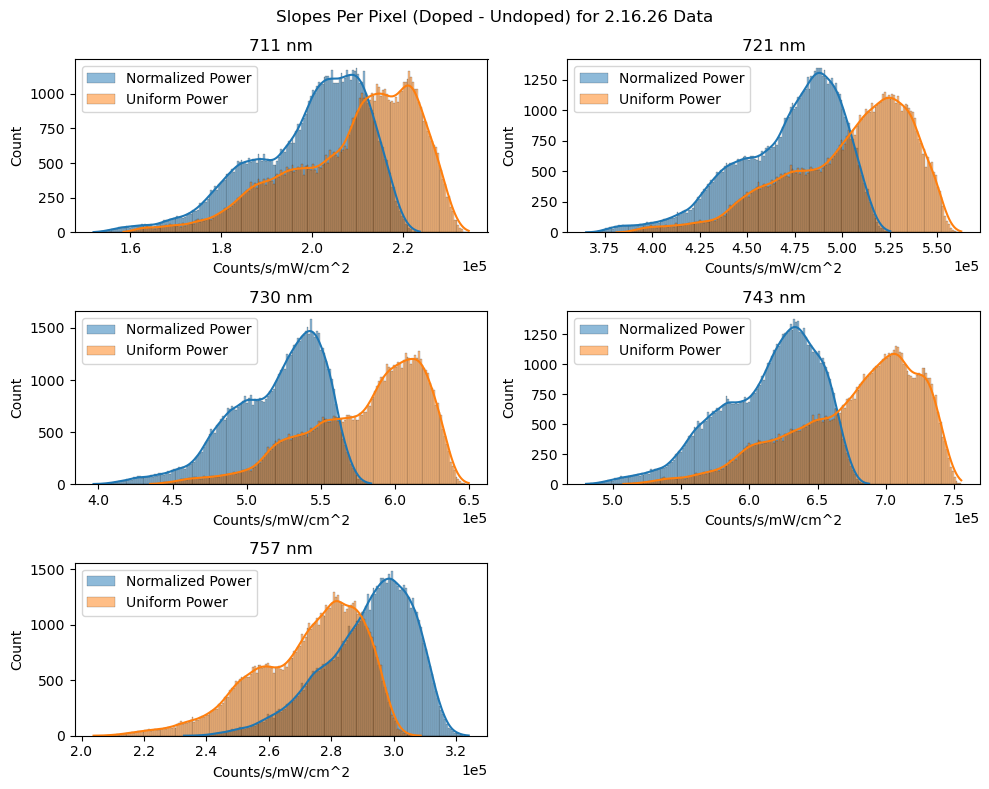

In [355]:
#graph comparisons
plt.figure(figsize=(10,8))
plt.suptitle("Slopes Per Pixel (Doped - Undoped) for 2.16.26 Data")
for i in range(len(allrows2)):
    x = int(i)
    plt.subplot(3,2, i+1)
    slopes_table2 = pd.DataFrame(allrows2[i])
    slopes_table = pd.DataFrame(allrows[i])
    histogram = np.concatenate([slopes_table["difference"], slopes_table2["difference"]])
    bins = np.linspace(histogram.min(), histogram.max(), 200)
    sns.histplot(slopes_table2["difference"], kde=True, bins=bins,  label="Normalized Power")
    sns.histplot(slopes_table["difference"], kde=True, bins=bins,  label="Uniform Power")
    plt.title(list(undoped_spe_dict)[i]+" nm")
    plt.ticklabel_format(axis='x', style='sci', scilimits=(5,5))
    plt.xlabel("Counts/s/mW/cm^2")
    print("average ROI slope of", list(undoped_nm_dict)[i], "nm:", slopes_table2["difference"].mean())
    print("STDEV difference between models for", list(undoped_nm_dict)[i], "nm:", slopes_table["difference"].std() - slopes_table2['difference'].std())


    plt.legend()
plt.tight_layout()

## everything past here does not work rn 

In [ ]:

bins=
plt.figure(figsize=(10,8))
slopes_table2 = pd.DataFrame(allrows2[i])
sns.histplot(slopes_table2["difference"], kde=True, bins=bins,  label=list(undoped_spe_dict)[i] + "nm")
slopes_table = pd.DataFrame(allrows[i])
sns.histplot(slopes_table["difference"], kde=True, bins=bins,  label=list(undoped_spe_dict)[i])

plt.legend()

In [ ]:
#normalize the power : divide counts at each pixel by the total sum of counts
fractionalPower = []

for i in range(len(countsPerPixelUnbiased)): 
    fractionalPower.append(countsPerPixelUnbiased[i] / np.sum(countsPerPixelUnbiased[i]))

In [ ]:
norm_power = []
#for each power, multiply by the per pixel fraction to get a power per pixel (intensity!) 
#doped
for i in range(len(averagePowerDoped)):
    norm_power.append(averagePowerDoped[i]*fractionalPower[i])
#undoped
norm_power_undoped = []
for i in range(len(averagePowerUndoped)):
    norm_power_undoped.append(averagePowerUndoped[i]*fractionalPower[i])
#divide intensity by area of the pixel to get it in mW/cm^2
norm_intensity_undoped = np.array(norm_power_undoped)/pixel_area
norm_intensity = np.array(norm_power)/pixel_area

In [ ]:
#cut intensity arrays down to the size of the ROI
intensityDopedROI = norm_intensity[:,roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]
intensityUndopedROI = norm_intensity_undoped[:,roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]

In [ ]:
#need array w x / y / undoped slope / doped slope / differences
#find slopes using polyfit, append to a list
rows = []
for y in range(roi_y):
    for x in range(roi_x):
        best, ignore = np.polyfit(intensity_doped, dcounts[:,y,x], 1)
        best1, ignore = np.polyfit(intensity_undoped, undcounts[:,y,x], 1)
        rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})

In [ ]:
rows2 = []
for y in range(roi_y):
    for x in range(roi_x):
        best, ignore = np.polyfit(intensityDopedROI[:,y,x], dcounts[:,y,x], 1)
        best1, ignore = np.polyfit(intensityUndopedROI[:,y,x], undcounts[:,y,x], 1)
        rows2.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})

In [ ]:
#convert list to dataframe for easy histograming
slopes_table = pd.DataFrame(rows)
slopes_table.head()
slopes_table2 = pd.DataFrame(rows2)


In [ ]:
histogram = np.concatenate([slopes_table["difference"], slopes_table2["difference"]])
bins = np.linspace(histogram.min(), histogram.max(), 200)

In [ ]:
#plot
plt.figure(figsize=(10,8))
sns.histplot(slopes_table["difference"], kde=True, bins=bins,edgecolor='blue', label='Uniform Beam Model')
sns.histplot(slopes_table2["difference"], kde=True, bins=bins, edgecolor='red', label='Normalized Model')
#sns.histplot(slopes_table3["difference"], kde=True, bins=200,edgecolor='green', label='Ratio')

plt.xlabel("Slope (counts/s/mW/cm^2)",fontsize=15)
plt.ylabel("Occurrences", fontsize=15)
plt.title("Slope Differences Per Cm^2 (Rb in Kr Film Minus Empty Kr Film)",fontsize=20)
plt.legend()
plt.show()

In [ ]:
r = 2.54/2
z_film = 98 #cm
#given x and given y we can find hypotenuse which is r for each pixel (for distance from center of film)
film_size_x = np.linspace(0,1024,1024)
film_size_y = np.linspace(0,1024,1024)
dist = np.zeros((1024, 1024, 2))
for x in range(len(film_size_x)):
    for y in range(len(film_size_y)):
        dist[x,y] = 511 - x , 511 - y

#dist = dist  * np.sqrt(pixel_area)

In [ ]:
#distance from center of lens
z_lens = 41.8 #cm
r_lens = 2.54
bin_size = (r_lens/4)
lens_size_x = np.linspace(-512,512,1024)
lens_size_y = np.linspace(-512,512, 1024)
lens_dist = np.zeros((1024,1024,2))

for x in range(len(lens_size_x)):
    for y in range(len(lens_size_y)):
        lens_dist[x,y] = 511 - x , 511 - y

#lens_dist = lens_dist * bin_size

In [ ]:
print((lens_dist_x))
lensgrid = np.zeros((4,4))
sa = np.zeros((1024,1024))
#print(lensgrid)

In [ ]:
r = 2.54/2 
z_film = 98 #cm
# film_size_x = np.linspace(0,1024,1024)
# film_size_y = np.linspace(0,1024,1024)

r_lens = 5.08/2
z_lens = 41.8
bin_size = (r_lens/4)
lens_size_x = np.linspace(-512,512, 4)
lens_size_y = np.linspace(-512,512, 4)
sa = np.zeros((1024,1024))

for x in range(len(sa[0])):
        for y in range(len(sa[1])):

            x_dist = (x - 511) * pixel_width
            y_dist = (y - 511) * pixel_width
            if np.sqrt(x_dist**2 + y_dist**2) > r:
                sa[x,y] = 0
                continue
            else:
                for a in range(len(lens_size_x)):
                    for b in range(len(lens_size_y)):

                        lx_dist = (a) * bin_size
                        ly_dist = (b) * bin_size
                        displacement = np.sqrt((lx_dist - x_dist)**2) + ((ly_dist - y_dist)**2) 
                        hyp = np.sqrt(z_lens**2 + displacement**2)
                                    
                        denom = 4*np.pi*((hyp**3))
                        sa[x,y] += (z_lens/denom)

So the issue here is that not only do we need the solid angle for each pixel (1024 x 1024) we also need the solid angle for each pixel, for each point on the lens. The addition of all of those solid angles divided by the total area of the sphere should give us the fraction of photons hitting the detector (through the lens) 

In [ ]:

sa_roi = sa[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]

plt.imshow(sa_roi)
plt.colorbar()
plt.show()
plt.imshow(sa)
plt.colorbar()

In [ ]:
sa_df = []
for y in range(len(sa_roi)):          # number of rows
    for x in range(len(sa_roi[0])):   # number of columns
        sa_df.append({
            'x': x,
            'y': y,
            'value': sa_roi[y][x]})

In [ ]:
sa_df = pd.DataFrame(sa_df)

In [ ]:
sa_df.head()

In [ ]:
sa = slopes_table2['difference'] / sa_df['value']

In [ ]:
sns.histplot(sa)